# Autonomiczne parkowanie z użyciem uczenia przez wzmacnianie

Projekt implementuje agenta PPO (Proximal Policy Optimization), który uczy się parkować samochód w symulowanym środowisku 2D. Środowisko napisane jest w `gymnasium`, a trening odbywa się dwuetapowo (**curriculum learning**): najpierw z łagodnymi kryteriami sukcesu, następnie z surowymi.

In [ ]:
!pip install stable-baselines3[extra] gymnasium pygame matplotlib

Requirement already satisfied: gymnasium in /usr/local/lib/python3.12/dist-packages (1.2.3)
Requirement already satisfied: pygame in /usr/local/lib/python3.12/dist-packages (2.6.1)
Requirement already satisfied: matplotlib in /usr/local/lib/python3.12/dist-packages (3.10.0)
Requirement already satisfied: stable-baselines3[extra] in /usr/local/lib/python3.12/dist-packages (2.8.0)
Requirement already satisfied: numpy<3.0,>=1.20 in /usr/local/lib/python3.12/dist-packages (from 
stable-baselines3[extra]) (2.0.2)
Requirement already satisfied: torch<3.0,>=2.3 in /usr/local/lib/python3.12/dist-packages (from 
stable-baselines3[extra]) (2.10.0+cpu)
Requirement already satisfied: cloudpickle in /usr/local/lib/python3.12/dist-packages (from 
stable-baselines3[extra]) (3.1.2)
Requirement already satisfied: pandas in /usr/local/lib/python3.12/dist-packages (from stable-baselines3[extra]) 
(2.2.2)

Requirement already satisfied: opencv-python in /usr/local/lib/python3.12/dist-packages (from 
stable-baselines3[extra]) (4.13.0.92)
Requirement already satisfied: pygame-ce in /usr/local/lib/python3.12/dist-packages (from stable-baselines3[extra])
(2.5.7)

Requirement already satisfied: tensorboard>=2.9.1 in /usr/local/lib/python3.12/dist-packages (from 
stable-baselines3[extra]) (2.20.0)

Requirement already satisfied: psutil in /usr/local/lib/python3.12/dist-packages (from stable-baselines3[extra]) 
(5.9.5)

Requirement already satisfied: tqdm in /usr/local/lib/python3.12/dist-packages (from stable-baselines3[extra]) 
(4.67.3)
Requirement already satisfied: rich in /usr/local/lib/python3.12/dist-packages (from stable-baselines3[extra]) 
(13.9.4)
Requirement already satisfied: ale-py>=0.9.0 in /usr/local/lib/python3.12/dist-packages (from 
stable-baselines3[extra]) (0.11.2)
Requirement already satisfied: pillow in /usr/local/lib/python3.12/dist-packages (from stable-baselines3[extra]) 
(11.3.0)
Requirement already satisfied: typing-extensions>=4.3.0 in /usr/local/lib/python3.12/dist-packages (from gymnasium)
(4.15.0)
Requirement already satisfied: farama-notifications>=0.0.1 in /usr/local/lib/python3.12/dist-packages (from 
gymnasium) (0.0.4)
Requirement already satisfied: contourpy>=1.0.1 in /usr/local/lib/python3.12/dist-packages (from matplotlib) 
(1.3.3)
Requirement already satisfied: cycler>=0.10 in /usr/local/lib/python3.12/dist-packages (from matplotlib) (0.12.1)
Requirement already satisfied: fonttools>=4.22.0 in /usr/local/lib/python3.12/dist-packages (from matplotlib) 
(4.62.1)
Requirement already satisfied: kiwisolver>=1.3.1 in /usr/local/lib/python3.12/dist-packages (from matplotlib) 
(1.5.0)
Requirement already satisfied: packaging>=20.0 in /usr/local/lib/python3.12/dist-packages (from matplotlib) (26.1)
Requirement already satisfied: pyparsing>=2.3.1 in /usr/local/lib/python3.12/dist-packages (from matplotlib) 
(3.3.2)
Requirement already satisfied: python-dateutil>=2.7 in /usr/local/lib/python3.12/dist-packages (from matplotlib) 
(2.9.0.post0)

Requirement already satisfied: six>=1.5 in /usr/local/lib/python3.12/dist-packages (from 
python-dateutil>=2.7->matplotlib) (1.17.0)
Requirement already satisfied: absl-py>=0.4 in /usr/local/lib/python3.12/dist-packages (from 
tensorboard>=2.9.1->stable-baselines3[extra]) (1.4.0)
Requirement already satisfied: grpcio>=1.48.2 in /usr/local/lib/python3.12/dist-packages (from 
tensorboard>=2.9.1->stable-baselines3[extra]) (1.80.0)
Requirement already satisfied: markdown>=2.6.8 in /usr/local/lib/python3.12/dist-packages (from 
tensorboard>=2.9.1->stable-baselines3[extra]) (3.10.2)
Requirement already satisfied: protobuf!=4.24.0,>=3.19.6 in /usr/local/lib/python3.12/dist-packages (from 
tensorboard>=2.9.1->stable-baselines3[extra]) (5.29.6)
Requirement already satisfied: setuptools>=41.0.0 in /usr/local/lib/python3.12/dist-packages (from 
tensorboard>=2.9.1->stable-baselines3[extra]) (75.2.0)
Requirement already satisfied: tensorboard-data-server<0.8.0,>=0.7.0 in /usr/local/lib/python3.12/dist-packages 
(from tensorboard>=2.9.1->stable-baselines3[extra]) (0.7.2)
Requirement already satisfied: werkzeug>=1.0.1 in /usr/local/lib/python3.12/dist-packages (from 
tensorboard>=2.9.1->stable-baselines3[extra]) (3.1.8)
Requirement already satisfied: filelock in /usr/local/lib/python3.12/dist-packages (from 
torch<3.0,>=2.3->stable-baselines3[extra]) (3.29.0)
Requirement already satisfied: sympy>=1.13.3 in /usr/local/lib/python3.12/dist-packages (from 
torch<3.0,>=2.3->stable-baselines3[extra]) (1.14.0)
Requirement already satisfied: networkx>=2.5.1 in /usr/local/lib/python3.12/dist-packages (from 
torch<3.0,>=2.3->stable-baselines3[extra]) (3.6.1)
Requirement already satisfied: jinja2 in /usr/local/lib/python3.12/dist-packages (from 
torch<3.0,>=2.3->stable-baselines3[extra]) (3.1.6)
Requirement already satisfied: fsspec>=0.8.5 in /usr/local/lib/python3.12/dist-packages (from 
torch<3.0,>=2.3->stable-baselines3[extra]) (2025.3.0)
Requirement already satisfied: pytz>=2020.1 in /usr/local/lib/python3.12/dist-packages (from 
pandas->stable-baselines3[extra]) (2025.2)

Requirement already satisfied: tzdata>=2022.7 in /usr/local/lib/python3.12/dist-packages (from 
pandas->stable-baselines3[extra]) (2026.1)

Requirement already satisfied: markdown-it-py>=2.2.0 in /usr/local/lib/python3.12/dist-packages (from 
rich->stable-baselines3[extra]) (4.0.0)
Requirement already satisfied: pygments<3.0.0,>=2.13.0 in /usr/local/lib/python3.12/dist-packages (from 
rich->stable-baselines3[extra]) (2.20.0)
Requirement already satisfied: mdurl~=0.1 in /usr/local/lib/python3.12/dist-packages (from 
markdown-it-py>=2.2.0->rich->stable-baselines3[extra]) (0.1.2)
Requirement already satisfied: mpmath<1.4,>=1.1.0 in /usr/local/lib/python3.12/dist-packages (from 
sympy>=1.13.3->torch<3.0,>=2.3->stable-baselines3[extra]) (1.3.0)
Requirement already satisfied: markupsafe>=2.1.1 in /usr/local/lib/python3.12/dist-packages (from 
werkzeug>=1.0.1->tensorboard>=2.9.1->stable-baselines3[extra]) (3.0.3)

In [ ]:
import os
# Ustawienie fałszywego sterownika wideo dla PyGame w środowisku bez monitora (tylko dla Colaba)
os.environ["SDL_VIDEODRIVER"] = "dummy"

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import pygame
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

## Środowisko parkingowe (`ParkingEnv`)

Środowisko modeluje prostokątną planszę 800×600 px. Agent steruje samochodem 4 akcjami: **przyspieszenie**, **hamowanie/wstecz**, **skręt w prawo**, **skręt w lewo**.

Obserwacja to wektor 14 liczb: pozycja i kąt auta, prędkość, pozycja miejsca docelowego i dwóch przeszkód oraz odległość i kierunek do celu.

Nagrody:
- `+200` za pomyślne zaparkowanie (blisko celu, odpowiedni kąt, mała prędkość)
- `-100` za kolizję z przeszkodą lub wyjazd poza planszę
- kara proporcjonalna do różnicy kąta przy zbliżaniu się do celu

In [ ]:
class ParkingEnv(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(self, render_mode=None, success_dist=5.0, success_angle=3.0, success_speed=0.5):
        super().__init__()
        self.render_mode = render_mode
        self.window = None
        self.clock = None

        self.success_dist = success_dist
        self.success_angle = success_angle
        self.success_speed = success_speed

        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=-1.0, high=1.0, shape=(14,), dtype=np.float32
        )
        self.prev_dist = None

    def _get_observation(self):
        dist = np.sqrt((self.car_x - self.target_x)**2 + (self.car_y - self.target_y)**2)
        norm_dist = np.clip(dist / 1000.0, 0.0, 1.0)
        dx = np.clip((self.target_x - self.car_x) / 800.0, -1.0, 1.0)
        dy = np.clip((self.target_y - self.car_y) / 600.0, -1.0, 1.0)

        obs = np.array([
            self.car_x / 800.0,
            self.car_y / 600.0,
            (self.car_angle % 360) / 180.0 - 1.0,
            self.car_speed / 5.0,
            self.target_x / 800.0,
            self.target_y / 600.0,
            self.target_angle / 180.0,
            self.obs1_x / 800.0,
            self.obs1_y / 600.0,
            self.obs2_x / 800.0,
            self.obs2_y / 600.0,
            dx, dy, norm_dist,
        ], dtype=np.float32)
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.car_x = 400.0 + random.uniform(-30, 30)
        self.car_y = 500.0 + random.uniform(-20, 20)
        self.car_angle = random.uniform(-10, 10)
        self.car_speed = 0.0

        parking_type = random.choice([0, 1])
        if parking_type == 0:
            self.target_angle = 0.0
            self.target_x, self.target_y = 400.0, 100.0
            self.obs1_x, self.obs1_y = self.target_x + 140.0, self.target_y
            self.obs2_x, self.obs2_y = self.target_x - 140.0, self.target_y
        else:
            self.target_angle = 90.0
            self.target_x, self.target_y = 400.0, 150.0
            self.obs1_x, self.obs1_y = self.target_x + 80.0, self.target_y
            self.obs2_x, self.obs2_y = self.target_x - 80.0, self.target_y

        self.step_count = 0
        self.prev_dist = np.sqrt((self.car_x - self.target_x)**2 + (self.car_y - self.target_y)**2)

        return self._get_observation(), {}

    def step(self, action):
        self.step_count += 1

        if action == 0: self.car_speed += 0.5
        elif action == 1: self.car_speed -= 0.5

        self.car_speed = max(-5.0, min(5.0, self.car_speed))

        if abs(self.car_speed) > 0.1:
            if action == 2: self.car_angle += 3.0
            elif action == 3: self.car_angle -= 3.0

        rad = np.deg2rad(self.car_angle)
        self.car_x += self.car_speed * np.cos(rad)
        self.car_y -= self.car_speed * np.sin(rad)

        dist = np.sqrt((self.car_x - self.target_x)**2 + (self.car_y - self.target_y)**2)
        angle_diff = abs((self.car_angle % 360) - self.target_angle)
        if angle_diff > 180: angle_diff = 360 - angle_diff

        dist_to_obs1 = np.sqrt((self.car_x - self.obs1_x)**2 + (self.car_y - self.obs1_y)**2)
        dist_to_obs2 = np.sqrt((self.car_x - self.obs2_x)**2 + (self.car_y - self.obs2_y)**2)

        reward = -0.05
        dist_improvement = self.prev_dist - dist
        reward += dist_improvement * 0.3
        self.prev_dist = dist

        if dist < 150:
            reward -= angle_diff * 0.004

        if dist_to_obs1 < 80: reward -= (80 - dist_to_obs1) * 0.01
        if dist_to_obs2 < 80: reward -= (80 - dist_to_obs2) * 0.01

        terminated, truncated = False, False

        if dist < self.success_dist and angle_diff < self.success_angle and abs(self.car_speed) < self.success_speed:
            reward = 200.0
            terminated = True

        if self.car_x < 0 or self.car_x > 800 or self.car_y < 0 or self.car_y > 600:
            reward = -100.0
            terminated = True

        if dist_to_obs1 < 50 or dist_to_obs2 < 50:
            reward = -100.0
            terminated = True

        if self.step_count >= 600:
            truncated = True

        info = {"dist": dist, "angle_diff": angle_diff}
        return self._get_observation(), reward, terminated, truncated, info

    def render(self):
        pass # Zignorowane w Colabie (nie potrzebujemy renderowania do treningu)

    def close(self):
        pass

In [ ]:
class PlottingLoggerCallback(BaseCallback):
    def __init__(self, check_freq: int, checkpoint_freq: int, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.checkpoint_freq = checkpoint_freq
        self.log_file = "postepy_ai.txt"
        self.best_mean_reward = -np.inf

        self.plot_steps = []
        self.plot_rewards = []
        self.plot_success_rates = []

        os.makedirs("checkpoints", exist_ok=True)

        with open(self.log_file, "w") as f:
            f.write("--- LOG TRENINGU AUTONOMICZNEGO PARKOWANIA ---\n")

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            if len(self.model.ep_info_buffer) > 0:
                mean_reward = np.mean([ep_info["r"] for ep_info in self.model.ep_info_buffer])
                successes = sum(1 for ep in self.model.ep_info_buffer if ep["r"] > 150)
                success_rate = successes / len(self.model.ep_info_buffer) * 100

                # Zapisujemy dane do wykresu
                self.plot_steps.append(self.num_timesteps)
                self.plot_rewards.append(mean_reward)
                self.plot_success_rates.append(success_rate)

                log_text = (
                    f"Krok: {self.num_timesteps:07d} | "
                    f"Srednia nagroda: {mean_reward:.2f} | "
                    f"Skutecznosc: {success_rate:.1f}%"
                )
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    log_text += " *** NOWY REKORD ***"

                print(log_text)
                with open(self.log_file, "a") as f:
                    f.write(log_text + "\n")

        if self.n_calls % self.checkpoint_freq == 0:
            step_label = f"{self.num_timesteps:07d}"
            self.model.save(f"checkpoints/model_{step_label}")
            self.training_env.save(f"checkpoints/vec_normalize_{step_label}.pkl")
            self.training_env.save("vec_normalize.pkl")

        return True

## Trening dwuetapowy (Curriculum Learning)

**Etap 1** (1 000 000 kroków) — luźne warunki: dopuszczalny błąd pozycji 30 px, kąta 20°, prędkości 1.5. Agent uczy się podstawowych manewrów.

**Etap 2** (1 500 000 kroków) — surowe warunki: 5 px / 3° / 0.5. Model z Etapu 1 jest fine-tunowany do precyzyjnego parkowania.

Oba etapy używają `VecNormalize` do normalizacji obserwacji oraz 4 równoległych środowisk dla wydajności.

In [ ]:
# ETAP 1: Trening z luźnymi warunkami
def make_env_easy():
    def _init():
        env = ParkingEnv(render_mode=None, success_dist=30.0, success_angle=20.0, success_speed=1.5)
        env = Monitor(env)
        return env
    return _init

N_ENVS = 4

env_easy = DummyVecEnv([make_env_easy() for _ in range(N_ENVS)])
env_easy = VecNormalize(env_easy, norm_obs=True, norm_reward=True, clip_obs=10.0)

eval_env_easy = DummyVecEnv([make_env_easy()])
eval_env_easy = VecNormalize(eval_env_easy, norm_obs=True, norm_reward=False, clip_obs=10.0)

model_phase1 = PPO(
    "MlpPolicy",
    env_easy,
    verbose=0,
    policy_kwargs=dict(net_arch=[256, 256]),
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    learning_rate=3e-4,
    gamma=0.99
)

eval_callback_easy = EvalCallback(
    eval_env_easy,
    best_model_save_path="./best_model_etap1/",
    log_path="./eval_logs_etap1/",
    eval_freq=max(10_000 // N_ENVS, 1),
    n_eval_episodes=20,
    deterministic=True,
    verbose=0,
)

logger_callback = PlottingLoggerCallback(check_freq=5_000, checkpoint_freq=50_000)

print("ETAP 1...")
model_phase1.learn(
    total_timesteps=1_000_000,
    callback=[logger_callback, eval_callback_easy],
    progress_bar=False,
)

# Zapisujemy model i statystyki normalizacji z Etapu 1
model_phase1.save("model_etap1")
env_easy.save("vec_normalize_etap1.pkl")
env_easy.close()
eval_env_easy.close()

print("Etap 1 zakończony! Model zapisany jako model_etap1.zip")

ETAP 1...

Krok: 0020000 | Srednia nagroda: -132.56 | Skutecznosc: 0.0% *** NOWY REKORD ***

Krok: 0040000 | Srednia nagroda: -87.83 | Skutecznosc: 0.0% *** NOWY REKORD ***

Krok: 0060000 | Srednia nagroda: -55.85 | Skutecznosc: 0.0% *** NOWY REKORD ***

Krok: 0080000 | Srednia nagroda: -35.76 | Skutecznosc: 3.0% *** NOWY REKORD ***

...

Krok: 0940000 | Srednia nagroda: 293.95 | Skutecznosc: 100.0%

Krok: 0960000 | Srednia nagroda: 288.17 | Skutecznosc: 98.0%

Krok: 0980000 | Srednia nagroda: 293.29 | Skutecznosc: 100.0%

Krok: 1000000 | Srednia nagroda: 293.29 | Skutecznosc: 100.0%

Etap 1 zakończony! Model zapisany jako model_etap1.zip

In [ ]:
# ETAP 2: Fine-tuning z surowymi warunkami
def make_env_hard():
    def _init():
        env = ParkingEnv(render_mode=None, success_dist=5.0, success_angle=3.0, success_speed=0.5)
        env = Monitor(env)
        return env
    return _init

N_ENVS = 4

env_hard = DummyVecEnv([make_env_hard() for _ in range(N_ENVS)])
env_hard = VecNormalize.load("vec_normalize_etap1.pkl", env_hard)
env_hard.training = True
env_hard.norm_reward = True

eval_env_hard = DummyVecEnv([make_env_hard()])
eval_env_hard = VecNormalize.load("vec_normalize_etap1.pkl", eval_env_hard)
eval_env_hard.training = False
eval_env_hard.norm_reward = False

model_final = PPO.load("model_etap1", env=env_hard)

eval_callback_hard = EvalCallback(
    eval_env_hard,
    best_model_save_path="./best_model_final/",
    log_path="./eval_logs_final/",
    eval_freq=max(10_000 // N_ENVS, 1),
    n_eval_episodes=20,
    deterministic=True,
    verbose=0,
)

logger_callback_phase2 = PlottingLoggerCallback(check_freq=5_000, checkpoint_freq=50_000)

print("ETAP 2...")
model_final.learn(
    total_timesteps=1_500_000,
    callback=[logger_callback_phase2, eval_callback_hard],
    progress_bar=False,
)
# Zapis ostateczny
model_final.save("parking_ai_final")
env_hard.save("vec_normalize_final.pkl")
env_hard.close()
eval_env_hard.close()

print("Etap 2 zakończony! Ostateczny model zapisany jako parking_ai_final.zip")

ETAP 2...

Krok: 0020000 | Srednia nagroda: -25.00 | Skutecznosc: 5.7% *** NOWY REKORD ***

Krok: 0040000 | Srednia nagroda: 62.52 | Skutecznosc: 24.4% *** NOWY REKORD ***

Krok: 0060000 | Srednia nagroda: 143.15 | Skutecznosc: 42.0% *** NOWY REKORD ***

Krok: 0080000 | Srednia nagroda: 165.59 | Skutecznosc: 47.0% *** NOWY REKORD ***

...

Krok: 1440000 | Srednia nagroda: 294.90 | Skutecznosc: 99.0%

Krok: 1460000 | Srednia nagroda: 295.73 | Skutecznosc: 99.0%

Krok: 1480000 | Srednia nagroda: 281.90 | Skutecznosc: 93.0%

Krok: 1500000 | Srednia nagroda: 291.66 | Skutecznosc: 97.0%

Etap 2 zakończony! Ostateczny model zapisany jako parking_ai_final.zip

## Wizualizacja wyników treningu

Poniższy wykres pokazuje przebieg treningu w obu etapach:
- **górny panel** — średnia nagroda epizodyczna
- **dolny panel** — odsetek zakończonych sukcesem epizodów

Pionowa czerwona linia oznacza moment przejścia z łatwych na trudne warunki.

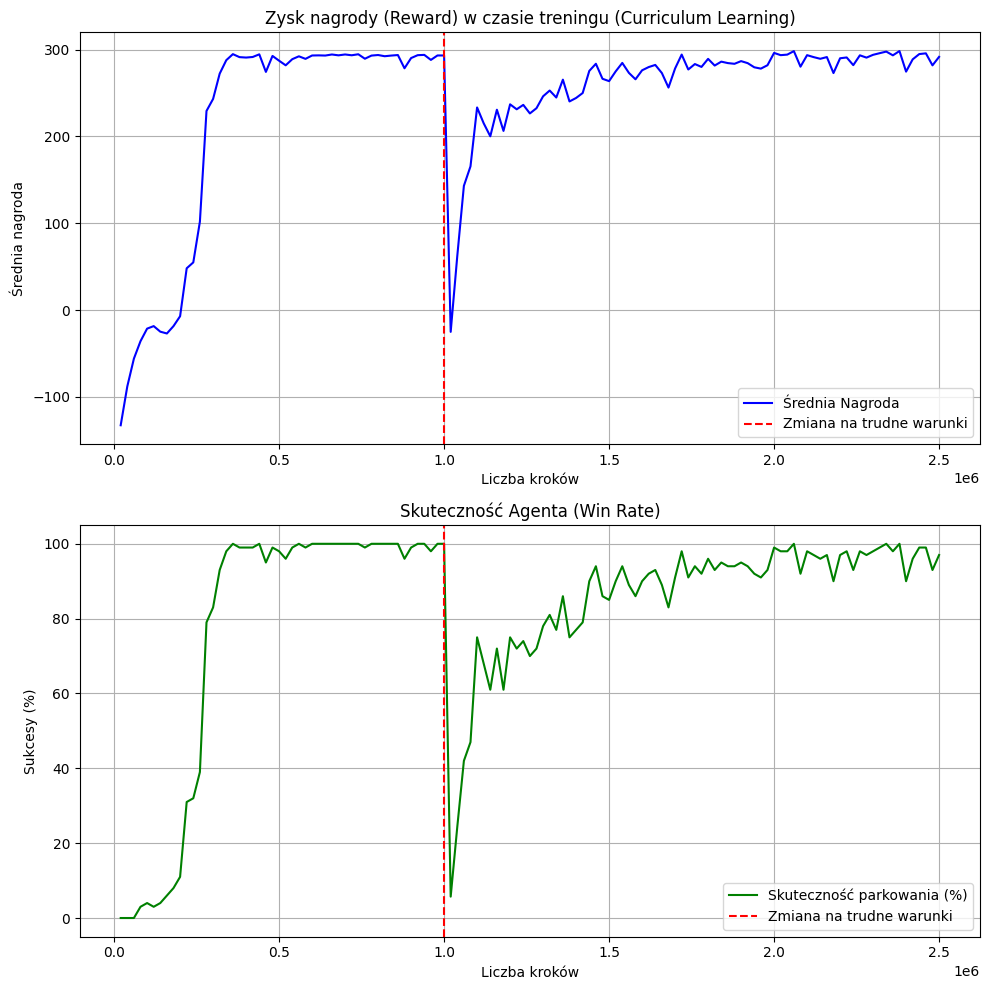

In [ ]:
import matplotlib.pyplot as plt

all_steps = logger_callback.plot_steps + [s + 1_000_000 for s in logger_callback_phase2.plot_steps]
all_rewards = logger_callback.plot_rewards + logger_callback_phase2.plot_rewards
all_success_rates = logger_callback.plot_success_rates + logger_callback_phase2.plot_success_rates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Wykres 1: Średnia Nagroda
ax1.plot(all_steps, all_rewards, 'b-', label='Średnia Nagroda')
ax1.axvline(x=1_000_000, color='r', linestyle='--', label='Zmiana na trudne warunki') # Linia podziału
ax1.set_title('Zysk nagrody (Reward) w czasie treningu (Curriculum Learning)')
ax1.set_xlabel('Liczba kroków')
ax1.set_ylabel('Średnia nagroda')
ax1.grid(True)
ax1.legend()

# Wykres 2: Skuteczność parkowania
ax2.plot(all_steps, all_success_rates, 'g-', label='Skuteczność parkowania (%)')
ax2.axvline(x=1_000_000, color='r', linestyle='--', label='Zmiana na trudne warunki') # Linia podziału
ax2.set_title('Skuteczność Agenta (Win Rate)')
ax2.set_xlabel('Liczba kroków')
ax2.set_ylabel('Sukcesy (%)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()